In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch
import torch.nn as nn
import timm
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


In [2]:
train_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
test_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

print(train_dataset.classes)
print(len(train_dataset))
print(len(test_dataset))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
14034
3000


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

device = torch.device("cuda")

In [6]:
# MASTER TRAINING FUNCTION

def train_and_evaluate(model_name, epochs=3):

    print(f"\nTraining {model_name}")

    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=6
    )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4
    )

    losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        losses.append(epoch_loss)

        print(
            f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}"
        )

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    print("\nRESULTS")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [7]:
# ConvNeXt MODEL

convnext_results = train_and_evaluate(
    "convnext_tiny",
    epochs=3
)


Training convnext_tiny


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/3 Loss: 0.2737
Epoch 2/3 Loss: 0.1586
Epoch 3/3 Loss: 0.1207

RESULTS
Accuracy : 0.9373333333333334
Precision: 0.9376128111032984
Recall   : 0.9373333333333334
F1 Score : 0.9371573276756541


In [8]:
# ViT MODEL

vit_results = train_and_evaluate(
    "vit_base_patch16_224",
    epochs=3
)

results.append(vit_results)


Training vit_base_patch16_224


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/3 Loss: 0.2854
Epoch 2/3 Loss: 0.1836
Epoch 3/3 Loss: 0.1538

RESULTS
Accuracy : 0.9146666666666666
Precision: 0.9150724597486088
Recall   : 0.9146666666666666
F1 Score : 0.9138443515359589


NameError: name 'results' is not defined

In [11]:
# SWIN MODEL

swin_results = train_and_evaluate(
    "swin_tiny_patch4_window7_224",
    epochs=3
)


Training swin_tiny_patch4_window7_224
Epoch 1/3 Loss: 0.2564
Epoch 2/3 Loss: 0.1510
Epoch 3/3 Loss: 0.1114

RESULTS
Accuracy : 0.9263333333333333
Precision: 0.9275844361038516
Recall   : 0.9263333333333333
F1 Score : 0.9256499124302432


In [12]:
# EVA MODEL

eva_results = train_and_evaluate(
    "eva02_base_patch14_224",
    epochs=2
)


Training eva02_base_patch14_224


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Epoch 1/2 Loss: 0.3913
Epoch 2/2 Loss: 0.2102

RESULTS
Accuracy : 0.8956666666666667
Precision: 0.9091876706812821
Recall   : 0.8956666666666667
F1 Score : 0.8957335864224406


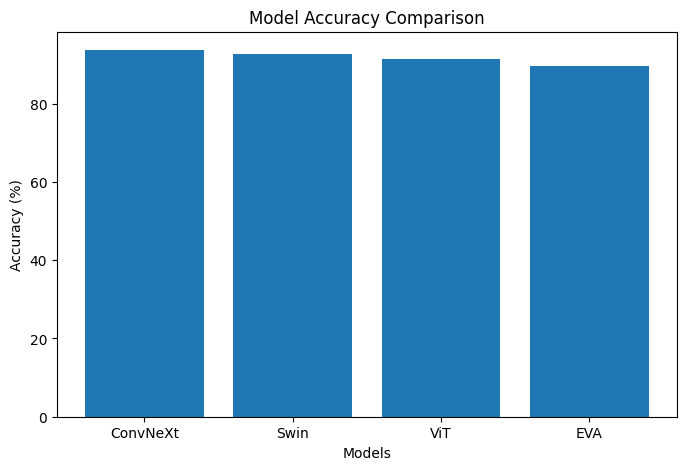

In [14]:
# COMPARISON CHART

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Model": ["ConvNeXt", "Swin", "ViT", "EVA"],
    "Accuracy": [93.73, 92.63, 91.47, 89.57]
})

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")

plt.show()

In [25]:
# CONFUSION MATRIX - ConvNeXt

model = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    num_classes=6
).to(device)

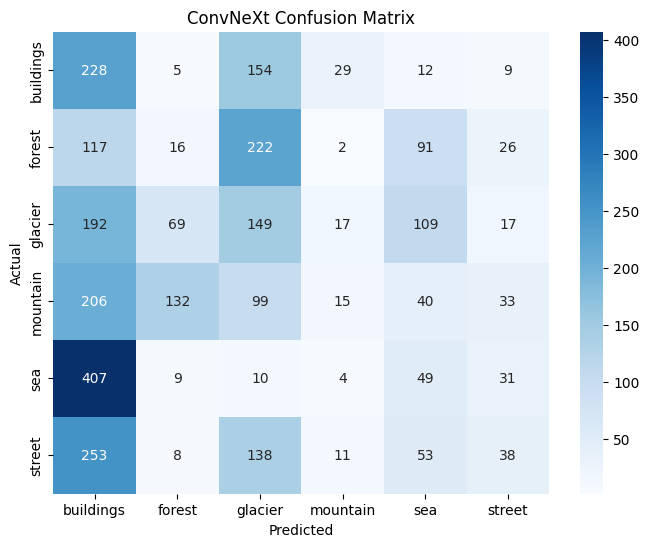

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("ConvNeXt Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
# CONFUSION MATRIX - ViT

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=6
).to(device)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

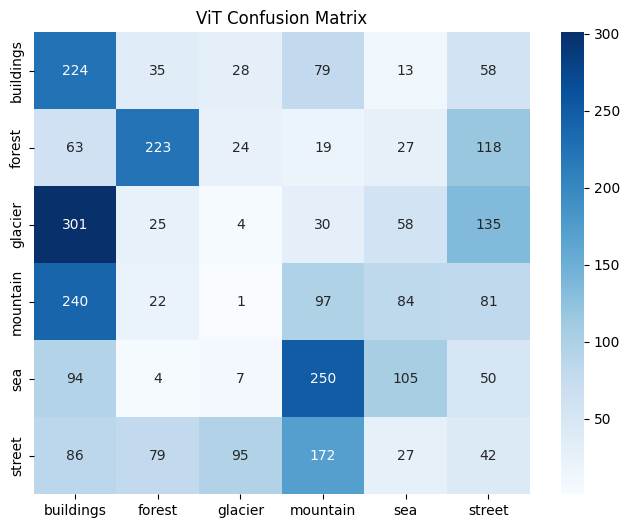

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("ViT Confusion Matrix")
plt

In [31]:
# CONFUSION MATRIX - SWIN 

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=6
).to(device)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

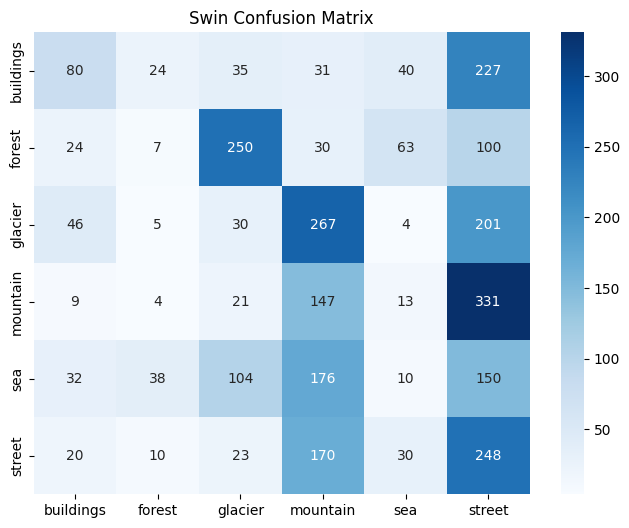

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("Swin Confusion Matrix")
plt

In [33]:
# CONFUSION MATRIX - EVA

model = timm.create_model(
    "eva02_base_patch14_224",
    pretrained=True,
    num_classes=6
).to(device)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

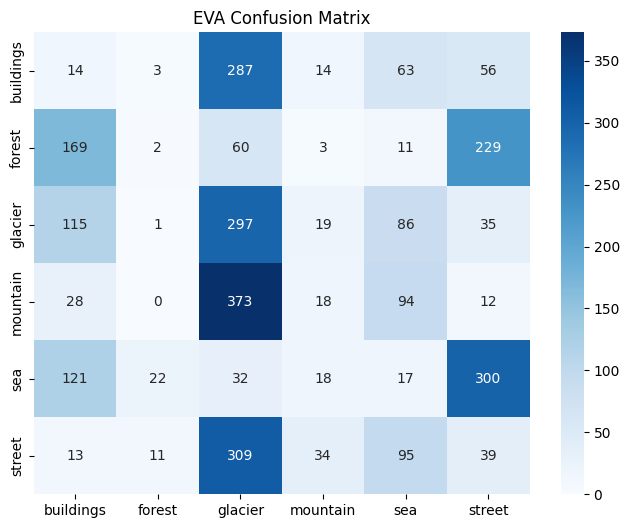

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("EVA Confusion Matrix")
plt

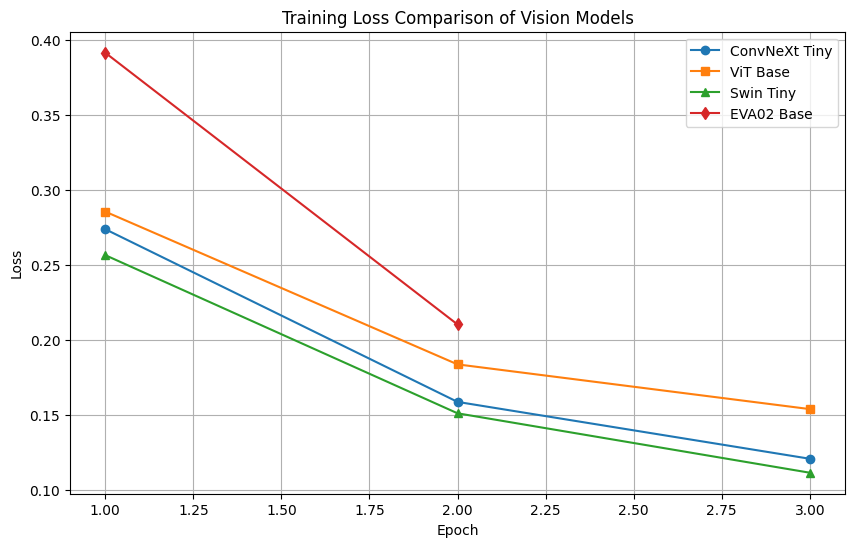

In [35]:
# LOSS GRAPH

import matplotlib.pyplot as plt

# Loss values from your runs

convnext_loss = [0.2737, 0.1586, 0.1207]

vit_loss = [0.2854, 0.1836, 0.1538]

swin_loss = [0.2564, 0.1510, 0.1114]

eva_loss = [0.3913, 0.2102]  # Only 2 epochs trained

# Epoch numbers
convnext_epochs = range(1, len(convnext_loss) + 1)
vit_epochs = range(1, len(vit_loss) + 1)
swin_epochs = range(1, len(swin_loss) + 1)
eva_epochs = range(1, len(eva_loss) + 1)

plt.figure(figsize=(10, 6))

plt.plot(convnext_epochs, convnext_loss, marker='o', label='ConvNeXt Tiny')
plt.plot(vit_epochs, vit_loss, marker='s', label='ViT Base')
plt.plot(swin_epochs, swin_loss, marker='^', label='Swin Tiny')
plt.plot(eva_epochs, eva_loss, marker='d', label='EVA02 Base')

plt.title('Training Loss Comparison of Vision Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()